# A3 — Econometric and residual diagnostics

This notebook reads saved Phase A3 outputs. It does not retrain models.

The residual autocorrelation tests use horizon-spaced residuals so that serial dependence is not mechanically created by overlapping future-return targets. The final 20% exploratory holdout remains unused.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

current = Path.cwd()
project_root = current.parent if current.name == "notebooks" else current
tables = project_root / "reports" / "tables"

summary = pd.read_csv(tables / "diagnostics_summary.csv")
folds = {
    h: pd.read_csv(tables / f"diagnostics_h{h}_folds.csv")
    for h in (10, 50, 100)
}
time_buckets = {
    h: pd.read_csv(tables / f"diagnostics_h{h}_time_buckets.csv")
    for h in (10, 50, 100)
}
summary

,horizon,folds,mean_rank_ic,mean_mae_improvement_pct,mae_improvement_positive_folds,mean_nonzero_directional_accuracy,mean_calibration_slope,mean_calibration_intercept_bps,mean_residual_mean_bps,mean_residual_std_bps,mean_residual_acf_lag_1,mean_absolute_residual_acf_lag_1,residual_ljung_box_20_rejections_5pct,mean_mid_return_acf_lag_1,mean_squared_mid_return_acf_lag_1,time_buckets,time_buckets_positive_mae_improvement,time_buckets_positive_rank_ic
0,10,5,0.198175,-5.925138,0,0.601221,0.745414,0.004561,0.010043,0.385579,-0.097273,0.097273,5,-0.112192,0.15602,9,0,9
1,50,5,0.211135,-0.064534,4,0.570636,0.727446,-0.002455,0.027697,0.832645,-0.032010,0.048224,2,-0.112192,0.15602,9,5,9
2,100,5,0.164012,-3.095868,2,0.540337,0.683095,-0.043877,0.054816,1.233736,-0.018902,0.055835,2,-0.112192,0.15602,9,3,9


## 1. Market return dependence

,horizon,mean_mid_return_acf_lag_1,mean_squared_mid_return_acf_lag_1
0,10,-0.112192,0.15602
1,50,-0.112192,0.15602
2,100,-0.112192,0.15602


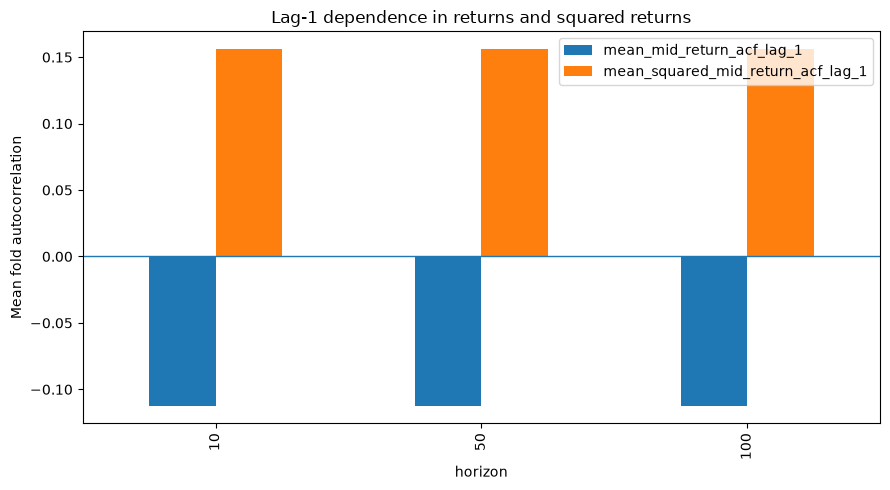

In [2]:
display(summary[[
    "horizon",
    "mean_mid_return_acf_lag_1",
    "mean_squared_mid_return_acf_lag_1",
]])

ax = summary.plot(
    x="horizon",
    y=["mean_mid_return_acf_lag_1", "mean_squared_mid_return_acf_lag_1"],
    kind="bar",
    figsize=(9, 5),
)
ax.axhline(0.0, linewidth=1)
ax.set_ylabel("Mean fold autocorrelation")
ax.set_title("Lag-1 dependence in returns and squared returns")
plt.tight_layout()
plt.show()

## 2. Non-overlapping residual dependence

,horizon,mean_residual_acf_lag_1,mean_absolute_residual_acf_lag_1,residual_ljung_box_20_rejections_5pct
0,10,-0.097273,0.097273,5
1,50,-0.032010,0.048224,2
2,100,-0.018902,0.055835,2


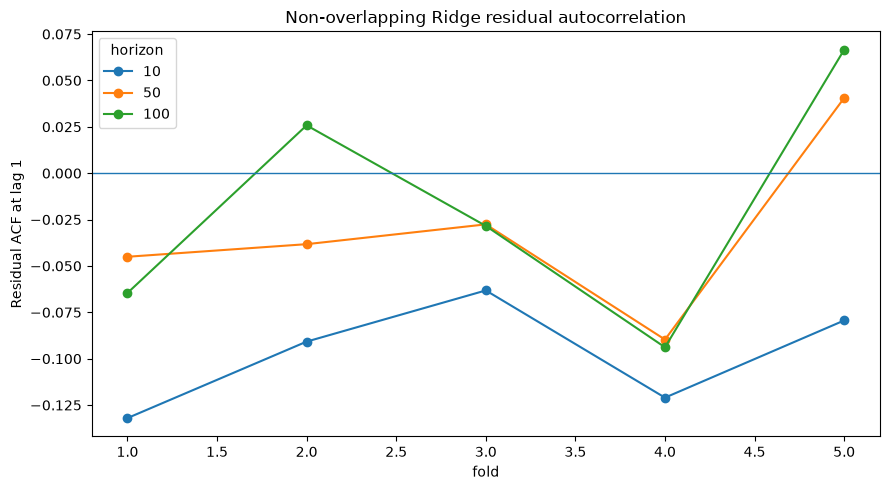

In [3]:
display(summary[[
    "horizon",
    "mean_residual_acf_lag_1",
    "mean_absolute_residual_acf_lag_1",
    "residual_ljung_box_20_rejections_5pct",
]])

combined = []
for horizon, frame in folds.items():
    selected = frame[["fold", "residual_acf_lag_1"]].copy()
    selected["horizon"] = horizon
    combined.append(selected)
residual_acf = pd.concat(combined, ignore_index=True)

pivot = residual_acf.pivot(index="fold", columns="horizon", values="residual_acf_lag_1")
ax = pivot.plot(marker="o", figsize=(9, 5))
ax.axhline(0.0, linewidth=1)
ax.set_ylabel("Residual ACF at lag 1")
ax.set_title("Non-overlapping Ridge residual autocorrelation")
plt.tight_layout()
plt.show()

## 3. Forecast calibration

,horizon,mean_calibration_slope,mean_calibration_intercept_bps,mean_residual_mean_bps,mean_residual_std_bps
0,10,0.745414,0.004561,0.010043,0.385579
1,50,0.727446,-0.002455,0.027697,0.832645
2,100,0.683095,-0.043877,0.054816,1.233736


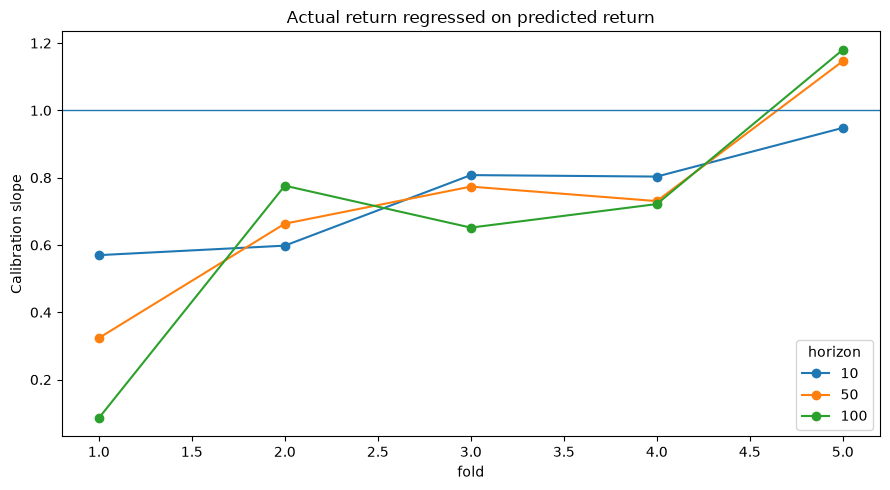

In [4]:
display(summary[[
    "horizon",
    "mean_calibration_slope",
    "mean_calibration_intercept_bps",
    "mean_residual_mean_bps",
    "mean_residual_std_bps",
]])

calibration = []
for horizon, frame in folds.items():
    selected = frame[["fold", "calibration_slope"]].copy()
    selected["horizon"] = horizon
    calibration.append(selected)
calibration = pd.concat(calibration, ignore_index=True)

pivot = calibration.pivot(index="fold", columns="horizon", values="calibration_slope")
ax = pivot.plot(marker="o", figsize=(9, 5))
ax.axhline(1.0, linewidth=1)
ax.set_ylabel("Calibration slope")
ax.set_title("Actual return regressed on predicted return")
plt.tight_layout()
plt.show()

## 4. Out-of-sample performance by clock-time bucket

In [5]:
for horizon, frame in time_buckets.items():
    print(f"{horizon}-event horizon")
    display(frame[[
        "time_bucket",
        "observations",
        "mean_spread_bps",
        "one_event_return_std_bps",
        "rank_ic",
        "mae_improvement_pct",
        "nonzero_directional_accuracy",
        "residual_mean_bps",
    ]])

10-event horizon


,time_bucket,observations,mean_spread_bps,one_event_return_std_bps,rank_ic,mae_improvement_pct,nonzero_directional_accuracy,residual_mean_bps
0,11:00-11:30,13563,2.997024,0.171011,0.154180,-3.025859,0.570978,0.027706
1,11:30-12:00,26199,2.910447,0.172025,0.129753,-8.909989,0.542675,0.072687
2,12:00-12:30,27809,2.673396,0.150287,0.177009,-7.488617,0.593270,-0.001700
3,12:30-13:00,20898,2.651304,0.144121,0.230144,-4.030776,0.614331,-0.004631
4,13:00-13:30,20769,2.415279,0.128729,0.214027,-7.736164,0.623072,-0.013125
5,13:30-14:00,26005,2.917708,0.160813,0.237241,-3.803037,0.616255,-0.007980
6,14:00-14:30,26155,2.275370,0.152536,0.183387,-6.258887,0.600215,0.000805
7,14:30-15:00,25788,2.120291,0.121740,0.218152,-5.717491,0.620587,0.012934
8,15:00-15:30,13009,2.305967,0.122418,0.239083,-4.173839,0.644296,0.000004


50-event horizon


,time_bucket,observations,mean_spread_bps,one_event_return_std_bps,rank_ic,mae_improvement_pct,nonzero_directional_accuracy,residual_mean_bps
0,11:00-11:30,13563,2.997024,0.171011,0.120113,-2.258005,0.528616,0.123277
1,11:30-12:00,26199,2.910447,0.172025,0.114491,-8.301483,0.520103,0.342581
2,12:00-12:30,27809,2.673396,0.150287,0.200956,-0.600638,0.572947,-0.062755
3,12:30-13:00,20898,2.651304,0.144121,0.240904,1.065677,0.574436,-0.071831
4,13:00-13:30,20769,2.415279,0.128729,0.198238,-0.467089,0.557386,-0.099459
5,13:30-14:00,26005,2.917708,0.160813,0.233458,1.813693,0.575825,-0.066183
6,14:00-14:30,26155,2.275370,0.152536,0.174793,0.967367,0.572171,-0.025528
7,14:30-15:00,25788,2.120291,0.121740,0.302403,4.244898,0.618458,0.090421
8,15:00-15:30,13009,2.305967,0.122418,0.259134,4.269028,0.617999,0.020483


100-event horizon


,time_bucket,observations,mean_spread_bps,one_event_return_std_bps,rank_ic,mae_improvement_pct,nonzero_directional_accuracy,residual_mean_bps
0,11:00-11:30,13563,2.997024,0.171011,0.134038,-3.622235,0.528292,0.291801
1,11:30-12:00,26199,2.910447,0.172025,0.018657,-23.125667,0.506874,0.843830
2,12:00-12:30,27809,2.673396,0.150287,0.179121,-0.747399,0.522998,-0.183546
3,12:30-13:00,20898,2.651304,0.144121,0.165367,-1.684036,0.516388,-0.190055
4,13:00-13:30,20769,2.415279,0.128729,0.122636,-1.000987,0.530272,-0.227644
5,13:30-14:00,26005,2.917708,0.160813,0.141971,-0.372817,0.541930,-0.152066
6,14:00-14:30,26155,2.275370,0.152536,0.152293,0.426718,0.552311,-0.102093
7,14:30-15:00,25788,2.120291,0.121740,0.260020,2.738297,0.573120,0.189402
8,15:00-15:30,13009,2.305967,0.122418,0.246728,4.222270,0.619678,0.034826


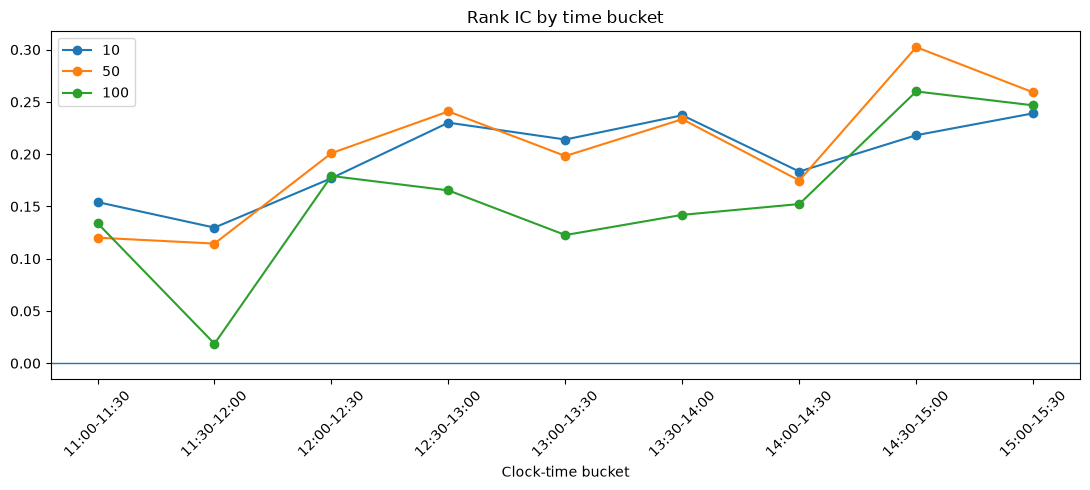

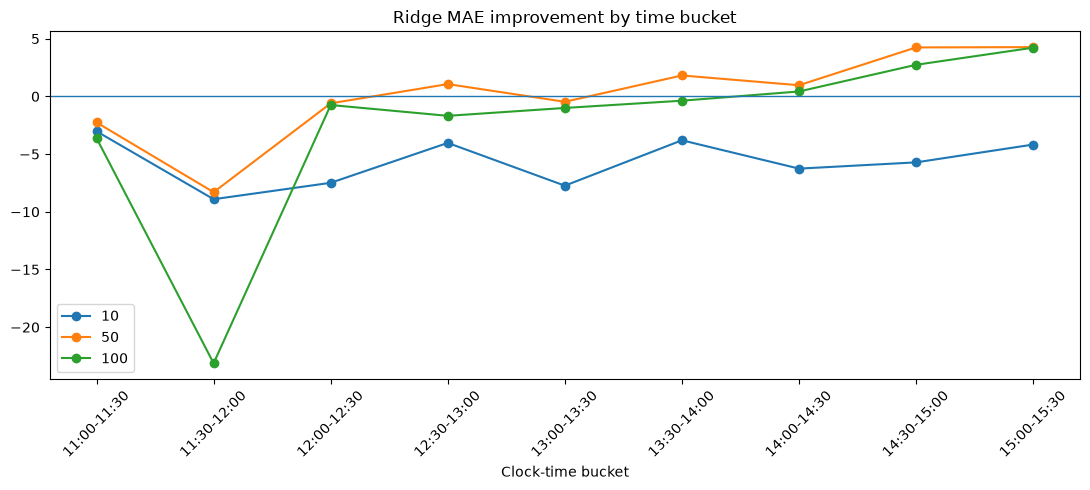

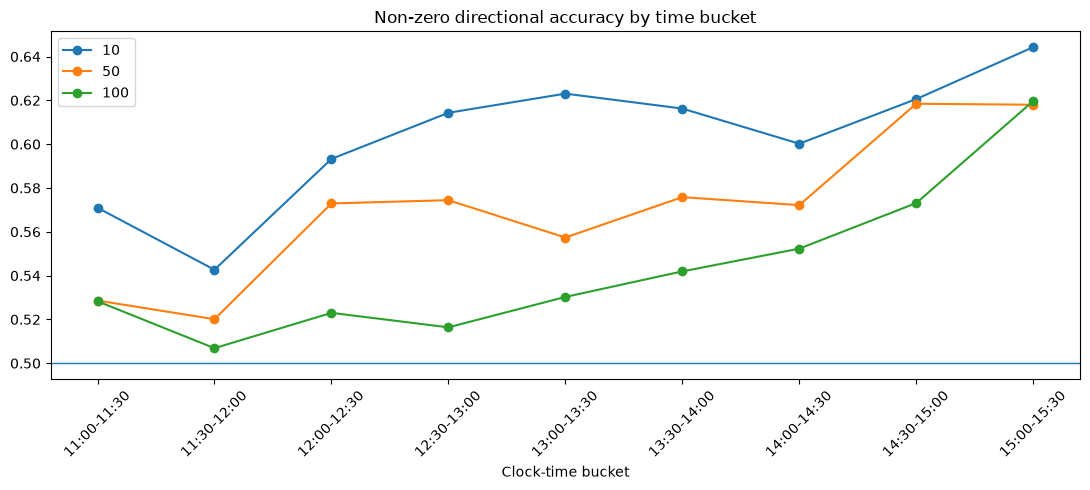

In [6]:
for metric, title in [
    ("rank_ic", "Rank IC by time bucket"),
    ("mae_improvement_pct", "Ridge MAE improvement by time bucket"),
    ("nonzero_directional_accuracy", "Non-zero directional accuracy by time bucket"),
]:
    comparison = None
    for horizon, frame in time_buckets.items():
        series = frame.set_index("time_bucket")[metric].rename(str(horizon))
        comparison = series.to_frame() if comparison is None else comparison.join(series, how="outer")
    ax = comparison.plot(marker="o", figsize=(11, 5))
    if metric == "rank_ic" or metric == "mae_improvement_pct":
        ax.axhline(0.0, linewidth=1)
    if metric == "nonzero_directional_accuracy":
        ax.axhline(0.50, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Clock-time bucket")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## Interpretation checklist

- Negative lag-1 mid-return autocorrelation can indicate short-term quote reversal or bid–ask/microstructure effects.
- Positive squared-return autocorrelation is evidence of volatility clustering.
- Ljung–Box rejection on horizon-spaced residuals means the linear model leaves serial structure unexplained.
- Calibration slope near 1 and intercept near 0 are ideal; a low slope indicates that predicted magnitudes are not well calibrated.
- Time buckets identify where the model becomes biased or loses accuracy. Phase B will formally test spread, liquidity, time-of-day and execution-cost regimes rather than tune the model here.